# Agentic AI - MultiAgent Pattern


A multi agent pattern or Supervisor pattern is popular to solve complex problem. In this multiple agents interact with each other to perform the resolution for the issue under the supervision of main agent.

**Note**: Connect to GPU (for google colab)

## Ollama Setup
So we will be using open source models from ollama as an llm/slm call to understand the concept

In [1]:
# let's download the ollama executables
!curl -fsSL https://ollama.com/install.sh | sh


>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [2]:
# serve the ollama
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [3]:
# pull the llm/slm models
# !ollama pull smollm:135m
# !ollama pull embeddinggemma:300m
# !ollama pull tinyllama:1.1b
# !ollama pull gemma3:270m
# !ollama pull gemma3:4b # having text and image support - by google
!ollama pull gemma3:1b # having text and image support - by google

In [4]:
# list the pulled models
!ollama list

NAME         ID              SIZE      MODIFIED               
gemma3:1b    8648f39daa8f    815 MB    Less than a second ago    


## LangChain/LangGraph Framework
we will be using langchain framework to implement the agents

In [5]:
# Installing required libraries
%%capture

!pip install langchain
!pip install langchain-ollama
!pip install langchain-core
!pip install langgraph
!pip install mermaid-py
!pip install pprintpp

In [6]:

# importing required libs

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Annotated
from IPython.display import display, Image
from pprint import pprint
import re
import random
import json
import operator
import json
import copy
import base64
import os

In [7]:
gemma1b_llm = ChatOllama(model="gemma3:1b", temperature=0.1) # for text

## **Use Case**: Let's create a workflow for Doctor E-Consulting.

So here is the approach

1.  Grab the Patient's Query.
2.  Assistent Doctor will analyze the query and identifies the which agetns need to call.
3.  Agent Router will call the agents on the basis of rules and state data.
4.  Then, Senior Doctor agent will summarize the observations.

Let's see how we can implement this.

let's create the node for each agent and specify their working

In [8]:
# specifying the members of the workflow

agent_members_and_capabilities = """
* **agent_analyze_lab_tests:** This agent helps to identify lab tests required to diagnose the issue.
* **agent_medicine_expert:** This agent helps to identify required medicines for medication to cure or supress the issue.
* **agent_severity_check:** This agent helps to classify the severity on the basis of patient's issue.
"""


Classes for State or Parsing

In [9]:
# adding state class for better parsing
class EConsultantAgent(TypedDict):
  required_agents: list[str]
  patient_query: str
  has_error: bool = False
  error_details: Annotated[list[str], operator.add]
  lab_test_needed: list
  medication_needed: list
  severity_index: str
  initial_observations: str

# class to define the next_step as a field fo model to predict out
class InitialObservationAgent(BaseModel):

  initial_observations : str = Field(
       description="A string type field to store the initial observations identified by the agent."
  )

  required_agents: list = Field(
      description="A list type field to store the required agent execution to address patient's health issue."
  )


class LabTestAgent(BaseModel):
  lab_test_needed : list = Field(
      description="A list type field to store the all lab test's name that are required"
)

class MedicationAgent(BaseModel):
  medication_needed : list = Field(
      description="A list type field to store the all the medicines needed to cure or supress patient's issue."
)



Initial Observer Node

In [20]:
# creating task supervisor node


def agent_initial_observer(state:EConsultantAgent):
  """This agent analyze the patient's issue and suggest further action need to be taken. """

  agent_initial_observer_sys_prompt = """Act as an expert assistant doctor in observing initial status of the patient.
  Analyze the patient's issue and identify which agents **(only name as list)** are required to further investigate the issue.
  You have these available agents to further investigate on the issue: {agent_members_and_capabilities}, and * **finish:** This can be returned in case no further investigation is required.
  You must generate short and clear summary for the patient issue including must have below things:
  * **Short and clear summar for issue:** Summary must be as doctor's terminolo
  * **Deitry suggestion:**
  * **Precautions need to be taken:**
  * **Any other comments**
  Then, you must identify the further agents needed to investigate the issue.
  """


  #defining runnable chain
  agent_initial_observer_llm_chain = ChatPromptTemplate.from_messages([
      ("system", agent_initial_observer_sys_prompt),
      ("human", "{patient_query}")
  ]) | gemma1b_llm.with_structured_output(InitialObservationAgent)
  #]) | gemma4b_llm

  # nice, let's invoke the model
  agent_initial_observer_llm_response  = agent_initial_observer_llm_chain.invoke({"patient_query": state["patient_query"],
                                                                    "agent_members_and_capabilities": agent_members_and_capabilities})

  try:
    return {"initial_observations" : agent_initial_observer_llm_response.initial_observations,
            "required_agents" : [ item['agent'] for item in agent_initial_observer_llm_response.required_agents]
            }

  except Exception as e:
    return {  "has_error": True,
              "error_details": ["AGENT:: INITIAL OBSERVER:::: " + str(e)],
              "required_agents" : ["finish"]
              }



Analyze Lab tets Node

In [23]:
# defining the plant identifier node to identify the plant name

def agent_analyze_lab_tests(state:EConsultantAgent):
  """ Agent analyze if any lab tests are required or not to diagnose the patient's issue."""

  analyze_lab_test_sys_prompt = """Act as a senior health labrotary expert identifying the required lab tests to further investigate upon patient's issue.
  On the basis of patient's issue summary, you must identify which test might **(only lab test name name)** be needed to further investigate the root cause.
  **Patient's Health Issue Summary:** {initial_observations}
  **Note:** In case none of the test is needed, return as "NA"
  """

  # creating a runnable
  analyze_lab_test_llm_chain = ChatPromptTemplate.from_messages([
      ("system", analyze_lab_test_sys_prompt),
      ("ai", "{initial_observations}")
  ]) | gemma1b_llm.with_structured_output(LabTestAgent)

  # let's invoke the chain
  analyze_lab_test_llm_response = analyze_lab_test_llm_chain.invoke({"initial_observations": state["initial_observations"]})

  try:
    return { "lab_test_needed": analyze_lab_test_llm_response.lab_test_needed }

  except Exception as e:
    return {
        "has_error": True,
        "error_details": ["AGENT:: ANALYZE LAB TESTS:::: " + str(e)],
        "lab_test_needed":  ["ERROR"]
        }


Medicine Expert Node

In [12]:
# creating node for gathering details
def agent_medicine_expert(state:EConsultantAgent):
  """This agent help patient by suggesting medications to cure the issue."""

  medicine_expert_sys_prompt = """Act as a senior expert in medicines.
  On the basis of patient's issue summary, you must suggest medication (list of medicines along with their proper dose) which  might be needed for cure or supress the issue.
  **Note:** Make sure you suggest medicine by considering a patient might undergo with these lab tests: {lab_test_needed}. In case lab tests has "NA", you may ignore this.
  **Patient's Health Issue Summary:** {initial_observations}
  **Note:** In case none of the test is needed, return as "NA"
  """

  medicine_expert_llm_chain = ChatPromptTemplate.from_messages([
      ("system", medicine_expert_sys_prompt),
      ("ai", "{lab_test_needed}"),
      ("ai", "{initial_observations}")
  ]) | gemma1b_llm.with_structured_output(MedicationAgent)

  # let's invoke the chain
  medicine_expert_llm_response = medicine_expert_llm_chain.invoke({"initial_observations": state["initial_observations"],
                                                                   "lab_test_needed": state["lab_test_needed"]})

  # extract the details
  try:
    return { "medication_needed": medicine_expert_llm_response.medication_needed }

  except Exception as e:

    return {
        "has_error": True,
        "error_details": ["AGENT:: MEDICINE EXPERT:::: " + str(e)],
        "medication_needed": ["ERROR"]
        }




Health Risk Score Calculator Node

In [13]:
# creating node for cost estimation
def agent_severity_check(state:EConsultantAgent):
  """This agent calculates the health risk score"""


  severity_check_sys_prompt = """Act as a senoir General Physcian Consultant.
  You have to analyze and initial observations and identify the severity as either of the one only: "NORMAL", "MODERATE", "HIGH", "CRITICAL"
  **Patient's Health Issue Summary:** {initial_observations}
  """

  # let's create the chain for this node
  severity_check_estimation_llm_chain = ChatPromptTemplate.from_messages([
      ("system", severity_check_sys_prompt),
      ("ai", "{initial_observations}")
  ]) | gemma1b_llm

  severity_check_estimation_llm_response = severity_check_estimation_llm_chain.invoke({
      "initial_observations" : state["initial_observations"]
  })

   # extract the details
  try:
    return { "severity_index": severity_check_estimation_llm_response.content}

  except Exception as e:

    return {
        "has_error": True,
        "error_details": ["AGENT:: SEVERITY CHECK:::: " + str(e)],
        "severity_index": ["ERROR"]
        }

Routing Node - Which will act as a Supervisor for us

In [14]:
def agent_routing(state:EConsultantAgent):
  """This agent rounting help to route the flow on the basis of state value"""
  print("****** EXECUTING - AGENT ROUTING ********")
  required_agents = state["required_agents"]

  if "agent_analyze_lab_tests" in required_agents and "lab_test_needed" not in state:
    return "agent_analyze_lab_tests"

  if "agent_medicine_expert" in required_agents and "medication_needed" not in state:
    return "agent_medicine_expert"

  if "agent_severity_check" in required_agents and "severity_index" not in state:
    return "agent_severity_check"

  if "finish":
    return "finish"


Constructing Graph

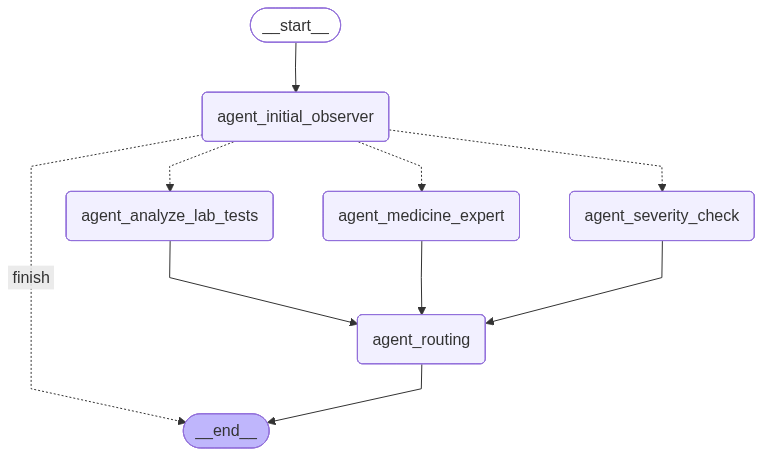

In [24]:
# let's define the graph

econsultingGraph = StateGraph(EConsultantAgent)

# adding nodes
econsultingGraph.add_node("agent_initial_observer", agent_initial_observer)
econsultingGraph.add_node("agent_analyze_lab_tests", agent_analyze_lab_tests)
econsultingGraph.add_node("agent_medicine_expert", agent_medicine_expert)
econsultingGraph.add_node("agent_severity_check", agent_severity_check)
econsultingGraph.add_node("agent_routing", agent_routing)


# adding edges
econsultingGraph.add_edge(START, "agent_initial_observer")
econsultingGraph.add_conditional_edges("agent_initial_observer", agent_routing, {
    "agent_analyze_lab_tests" : "agent_analyze_lab_tests",
    "agent_medicine_expert" : "agent_medicine_expert",
    "agent_severity_check"  : "agent_severity_check",
    "finish" : END
})

# looping back to members
econsultingGraph.add_edge("agent_analyze_lab_tests", "agent_routing")
econsultingGraph.add_edge("agent_medicine_expert", "agent_routing")
econsultingGraph.add_edge("agent_severity_check", "agent_routing")


# let's compile the graph
econsultingWorkflow = econsultingGraph.compile()

# let's visualize
Image(econsultingWorkflow.get_graph().draw_mermaid_png())

Perfect!!! Let's test this workflow

In [25]:
for chunk in econsultingWorkflow.stream(
    {"patient_query": "I am 30 years old male, feeling low and having fever since 5 days."
     }, stream_mode="values"):
  pprint(chunk)

{'error_details': [],
 'patient_query': 'I am 30 years old male, feeling low and having fever since '
                  '5 days.'}
****** EXECUTING - AGENT ROUTING ********
{'error_details': [],
 'initial_observations': 'Short and clear summar for issue:** The patient is '
                         'experiencing low mood and a fever for the past five '
                         'days. This warrants further investigation to '
                         'determine the underlying cause and potential '
                         'treatment.',
 'patient_query': 'I am 30 years old male, feeling low and having fever since '
                  '5 days.',
 'required_agents': ['agent_analyze_lab_tests']}
{'error_details': [],
 'initial_observations': 'Short and clear summar for issue:** The patient is '
                         'experiencing low mood and a fever for the past five '
                         'days. This warrants further investigation to '
                         'determine the underlyin

InvalidUpdateError: Expected dict, got finish
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE